# Libraries and setup


In [1]:
!pip install --quiet optuna lime

In [1]:
import os
import pandas as pd
import numpy as np
import random
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.impute import SimpleImputer , KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from optuna.samplers import RandomSampler
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score, mean_absolute_error ,  r2_score , root_mean_squared_error
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


In [2]:
pio.templates.default = "seaborn"

In [3]:
os.environ['SEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Right off the bat when opening the folder we downloaded we see bunch of files that seem random and the documentation in the website doesn't help much, even the .data files don't contain the column names. However upon reading the heart-disease.names we can see obtain the index of each row, furthermore the warning file states that the original cleveland.data has been corrupted, but the processed.cleveland.data is still intact, therefore we know we can only focus on the processed files which contain the 14 essential variables.

The files are csv and contain 14 columns, we index them according to the heart-disease.names file:

      -- 1. #3  (age)       
      -- 2. #4  (sex)       
      -- 3. #9  (cp)        
      -- 4. #10 (trestbps)  
      -- 5. #12 (chol)      
      -- 6. #16 (fbs)       
      -- 7. #19 (restecg)   
      -- 8. #32 (thalach)   
      -- 9. #38 (exang)     
      -- 10. #40 (oldpeak)   
      -- 11. #41 (slope)     
      -- 12. #44 (ca)        
      -- 13. #51 (thal)      
      -- 14. #58 (num)       (the predicted attribute)

In [5]:

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

# Exploratory Data Analysis (EDA)

In [4]:
#loading the dataframe
df = pd.read_csv('../data/original/heart.csv')

In [6]:
# replace ? by null
df = df.replace('?', np.nan)
#make all columns numeric
df = df.apply(pd.to_numeric, errors='coerce')
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [18]:
seeds = df[["age", "sex", "chol", "trestbps", "fbs"]].sample(n=5, replace=True)
seeds

,age,sex,chol,trestbps,fbs
243,48.0,1.0,256.0,130.0,1.0
831,47.0,1.0,226.0,150.0,0.0
504,60.0,1.0,216.0,142.0,0.0
130,57.0,0.0,354.0,120.0,0.0
484,62.0,1.0,0.0,NaN,0.0


## Data Quality check

### Missing values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing Count': missing, 'missing %': missing_pct.round(2)})
print(missing_df)

          missing Count  missing %
age                   0       0.00
sex                   0       0.00
cp                    0       0.00
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2       0.22
thalach              55       5.98
exang                55       5.98
oldpeak              62       6.74
slope               309      33.59
ca                  611      66.41
thal                486      52.83
num                   0       0.00


### Duplicates

In [9]:
dup_count = df.duplicated().sum()
print(f'duplicate rows: {dup_count}')

duplicate rows: 2


In [10]:
#remove duplicate
df.drop_duplicates(inplace=True)
print(f'duplicate rows after removal: {df.duplicated().sum()}')

duplicate rows after removal: 0


### Unique values

In [11]:
unique_vals = df.nunique().reset_index()
unique_vals.columns = ['Column', 'Unique Values']

fig = px.bar(unique_vals, x='Column', y='Unique Values',
             title='Unique Values Count per Column',
             color='Unique Values', color_continuous_scale='Blues',
             text='Unique Values')
fig.update_layout(xaxis_tickangle=-30)
fig.show()

print(unique_vals.to_string(index=False))

  Column  Unique Values
     age             50
     sex              2
      cp              4
trestbps             61
    chol            217
     fbs              2
 restecg              3
 thalach            119
   exang              2
 oldpeak             53
   slope              3
      ca              4
    thal              3
     num              5


We can see here that columns sex, cp, fbs, restecg, exang, slope, ca, thal are actually catergorical varaibles.

##  Target Variable Analysis

In [12]:
target_counts = df['num'].value_counts()
target_pct = df['num'].value_counts(normalize=True) * 100
target_df = pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)})
print(target_df)

     Count  Percentage
num                   
0      410       44.66
1      265       28.87
2      108       11.76
3      107       11.66
4       28        3.05


In [13]:
# change all rows whose 'num' value is bigger than 0 to 1 so that so that 0 = no disease presence 1 = disease presence
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

### Plotting

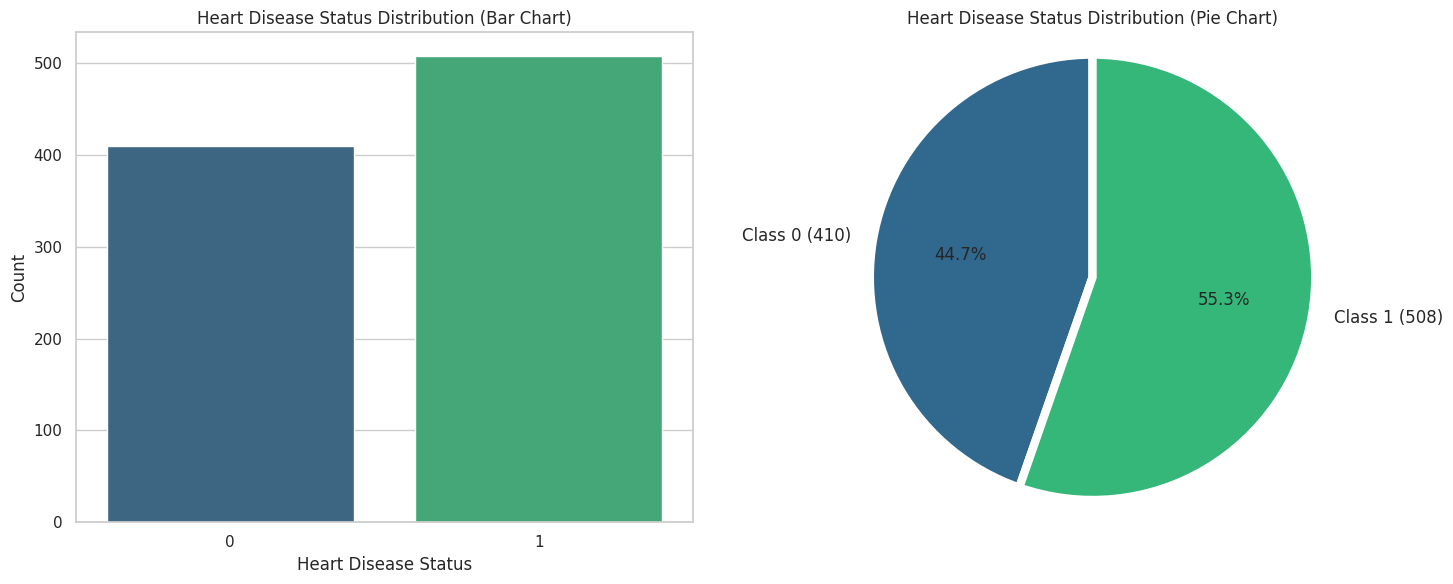

In [13]:
num_classes = df['num'].nunique()
colors = sns.color_palette('viridis', n_colors=num_classes)

disease_counts = df['num'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar Chart
sns.barplot(x=disease_counts.index, y=disease_counts.values, ax=axes[0], palette=colors)
axes[0].set_title('Heart Disease Status Distribution (Bar Chart)')
axes[0].set_xlabel('Heart Disease Status')
axes[0].set_ylabel('Count')
axes[0].set_xticks(disease_counts.index)

# Pie Chart
wedgeprops = {'edgecolor': 'white', 'linewidth': 6}

pie_labels = [f'Class {i} ({count})' for i, count in disease_counts.items()]
axes[1].pie(disease_counts.values, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops=wedgeprops, textprops={'fontsize': 12})
axes[1].set_title('Heart Disease Status Distribution (Pie Chart)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

The plots show that the dataset is highly imbalanced especially for class 4 which represents only 3.1% of the dataset.

**P.S:** Class 0 respresents no disease (control).

## Univariate Analysis

In [14]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

### Plotting histograms for numeric features

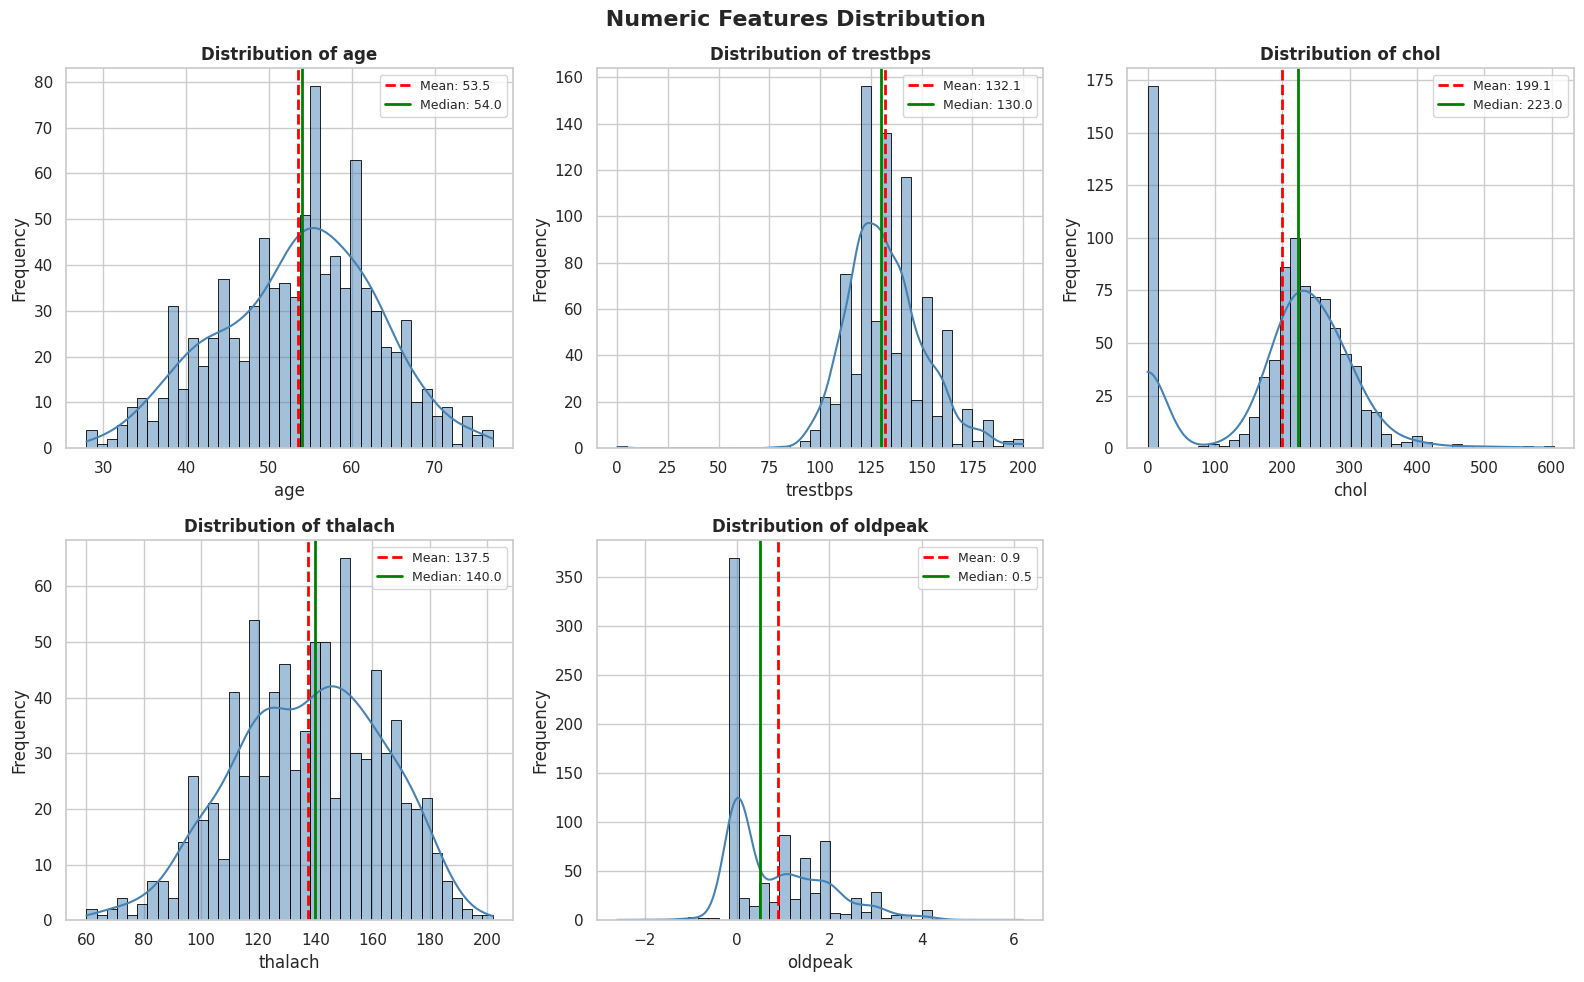

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

axes[5].axis('off')  # Hide last empty subplot
plt.suptitle(' Numeric Features Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

We can see that the Mean ≈ Median for almost all numerical variables, which means the features are clean and don't require heavy preprocessing.

### Box Plot for outlier detection

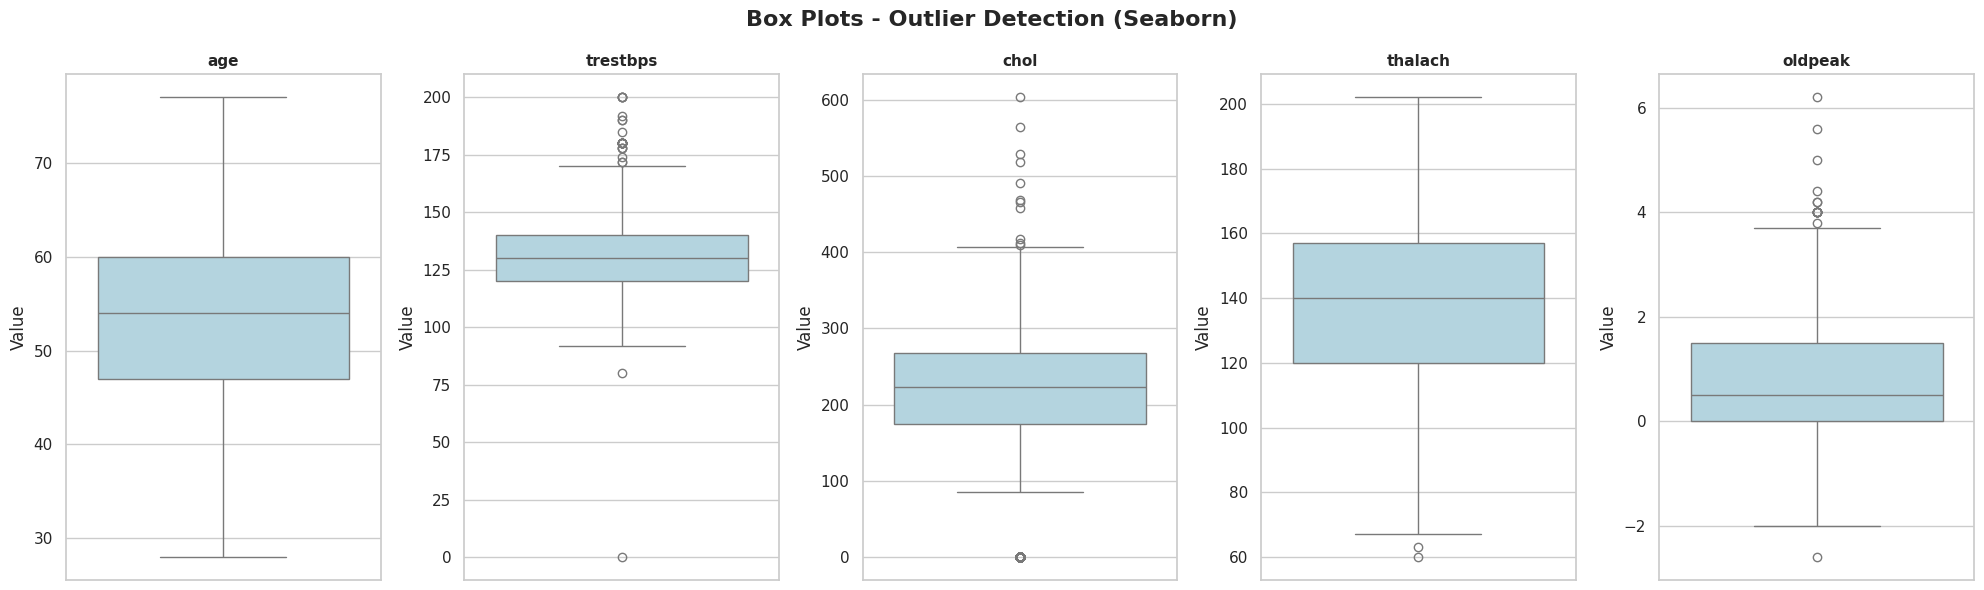

In [16]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Box Plots - Outlier Detection (Seaborn)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

We see that resting blood pressure, cholesterol and ST depression have the highest amount of outliers, however that doesn't mean we have to remove them because they can be medically possible measurements.

### Removing outliers
Resting blood pressure can never be 0 so we remove those values.

In [17]:
df=df[df['trestbps']!=0]

### Plotting bar charts for categorical variables

In [18]:
cat_labels = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-anginal Pain', 4: 'Asymptomatic'},
    'fbs': {0: 'Not fasting blood sugar', 1: 'Fasting blood sugar'},
    'restecg': {0: 'Normal', 1: 'ST-T wave abnormality', 2: 'Left ventricular hypertrophy'},
    'exang': {0: 'No exercise induced angina', 1: 'Exercise induced angina'},
    'slope': {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'ca': {0: '0', 1: '1', 2: '2', 3: '3'},
    'thal': {3: 'Normal', 6: 'Fixed Defect', 7: 'Reversable Defect'}
}

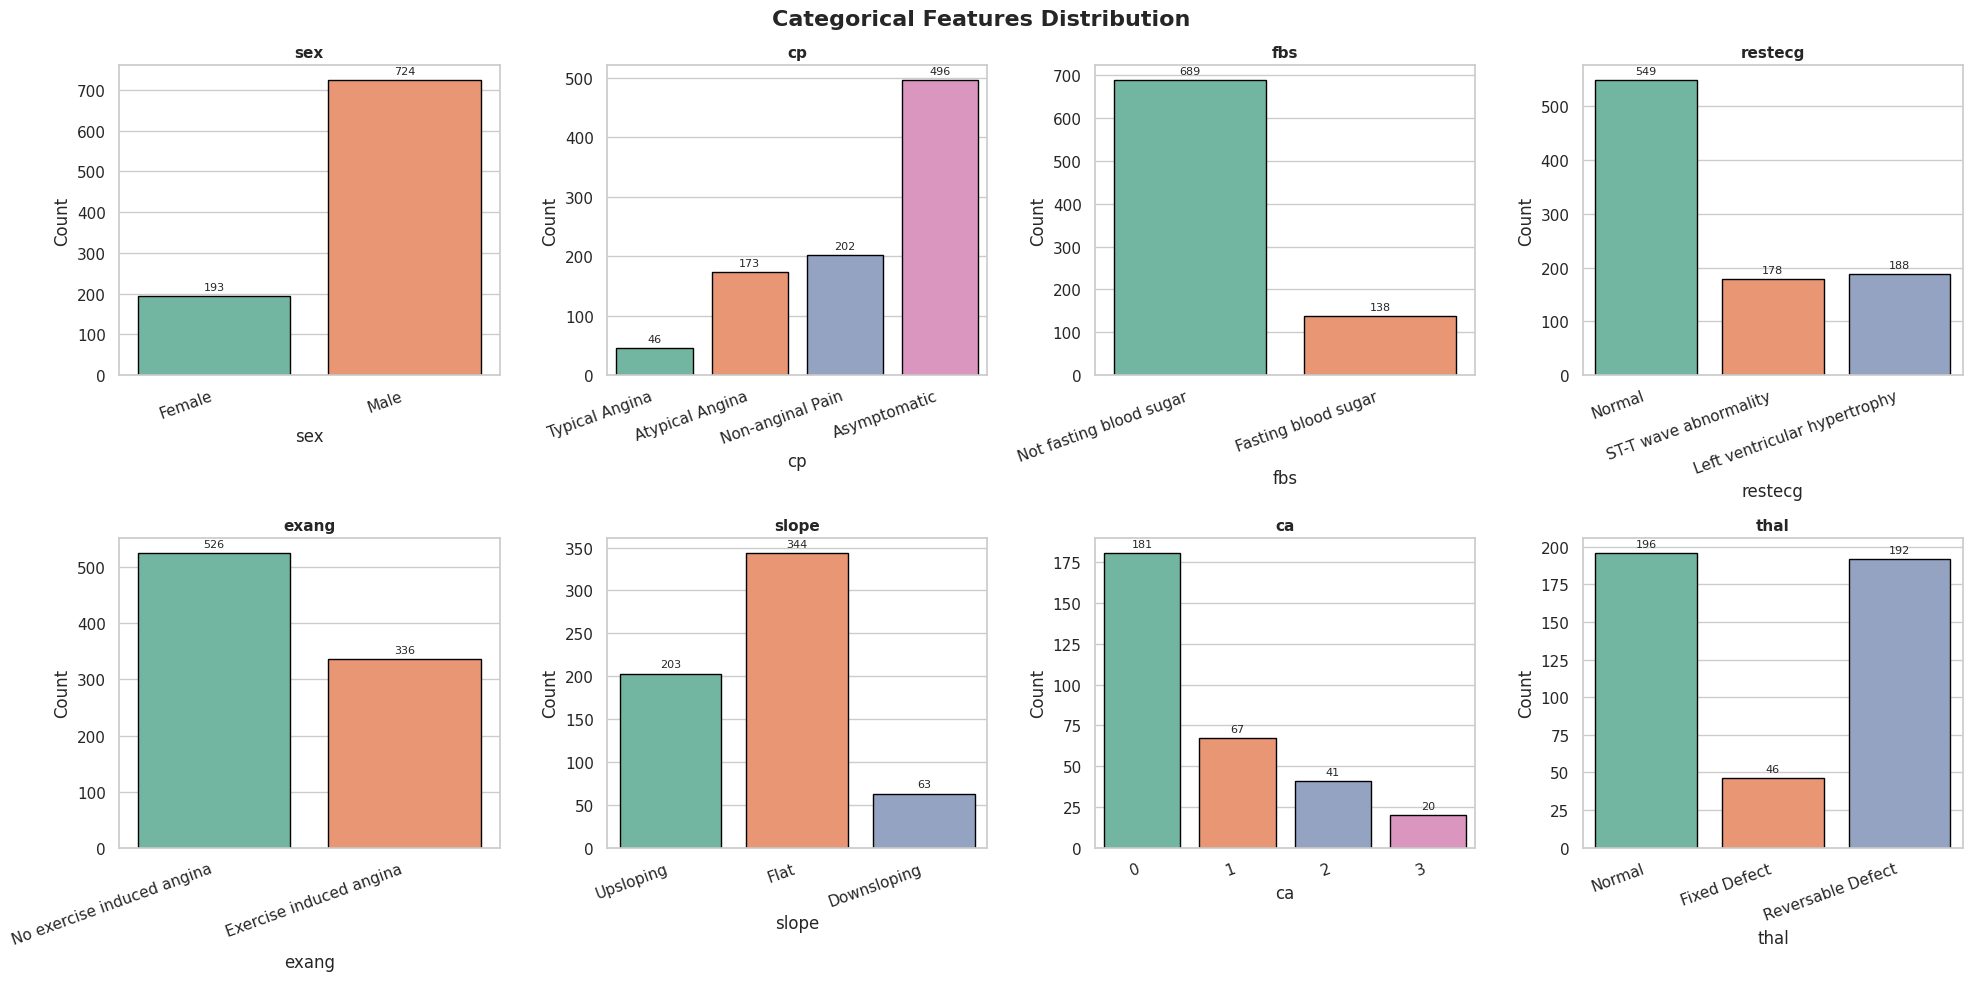

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', edgecolor='black')
    val_counts = df[col].value_counts().sort_index()
    labels = [cat_labels[col].get(k, str(k)) for k in val_counts.index]


    axes[i].set_xticks(range(len(labels)))
    axes[i].set_xticklabels(labels, rotation=20, ha='right') # Using ha='right' to ensure labels are aligned well

    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=8, padding=3)

plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

The dataset is gender-imbalanced. Model may be slightly biased toward male patterns.


## Multivariate Analysis
How does each feature relate to heart disease?

### Numeric Features vs Heart Disease - Box Plots

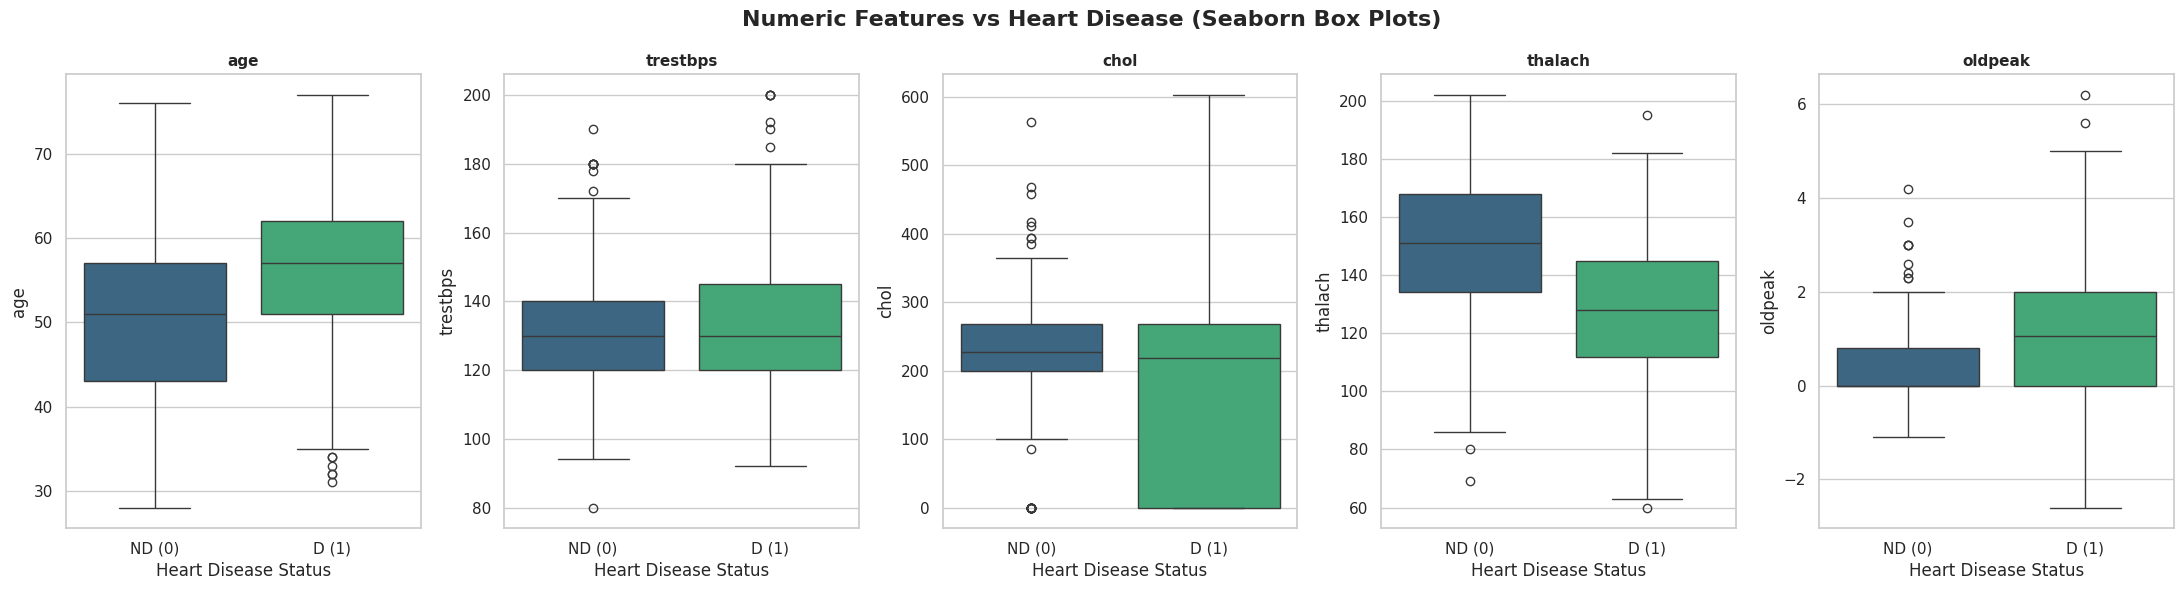

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

unique_num_values = sorted(df['num'].unique())
num_classes_count = len(unique_num_values)
num_palette = sns.color_palette('viridis', n_colors=num_classes_count)

# Class 0 is 'No Disease', and others are 'Disease (Class X)'
class_labels = {0: 'ND (0)'}
for c in unique_num_values:
    if c != 0:
        class_labels[c] = f'D ({int(c)})'

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='num', y=col, ax=axes[i], palette=num_palette)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Heart Disease Status')
    axes[i].set_ylabel(col)
    axes[i].set_xticks(unique_num_values)
    axes[i].set_xticklabels([class_labels.get(c, f'Class {int(c)}') for c in unique_num_values], rotation=0)

plt.suptitle('Numeric Features vs Heart Disease (Seaborn Box Plots)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('bivariate_numeric_seaborn.png', dpi=150, bbox_inches='tight')
plt.show()

We can see that the boxes are of different heights which means these features will be usefull for prediction.


### Categorical Features vs Heart Disease - Stacked Bar

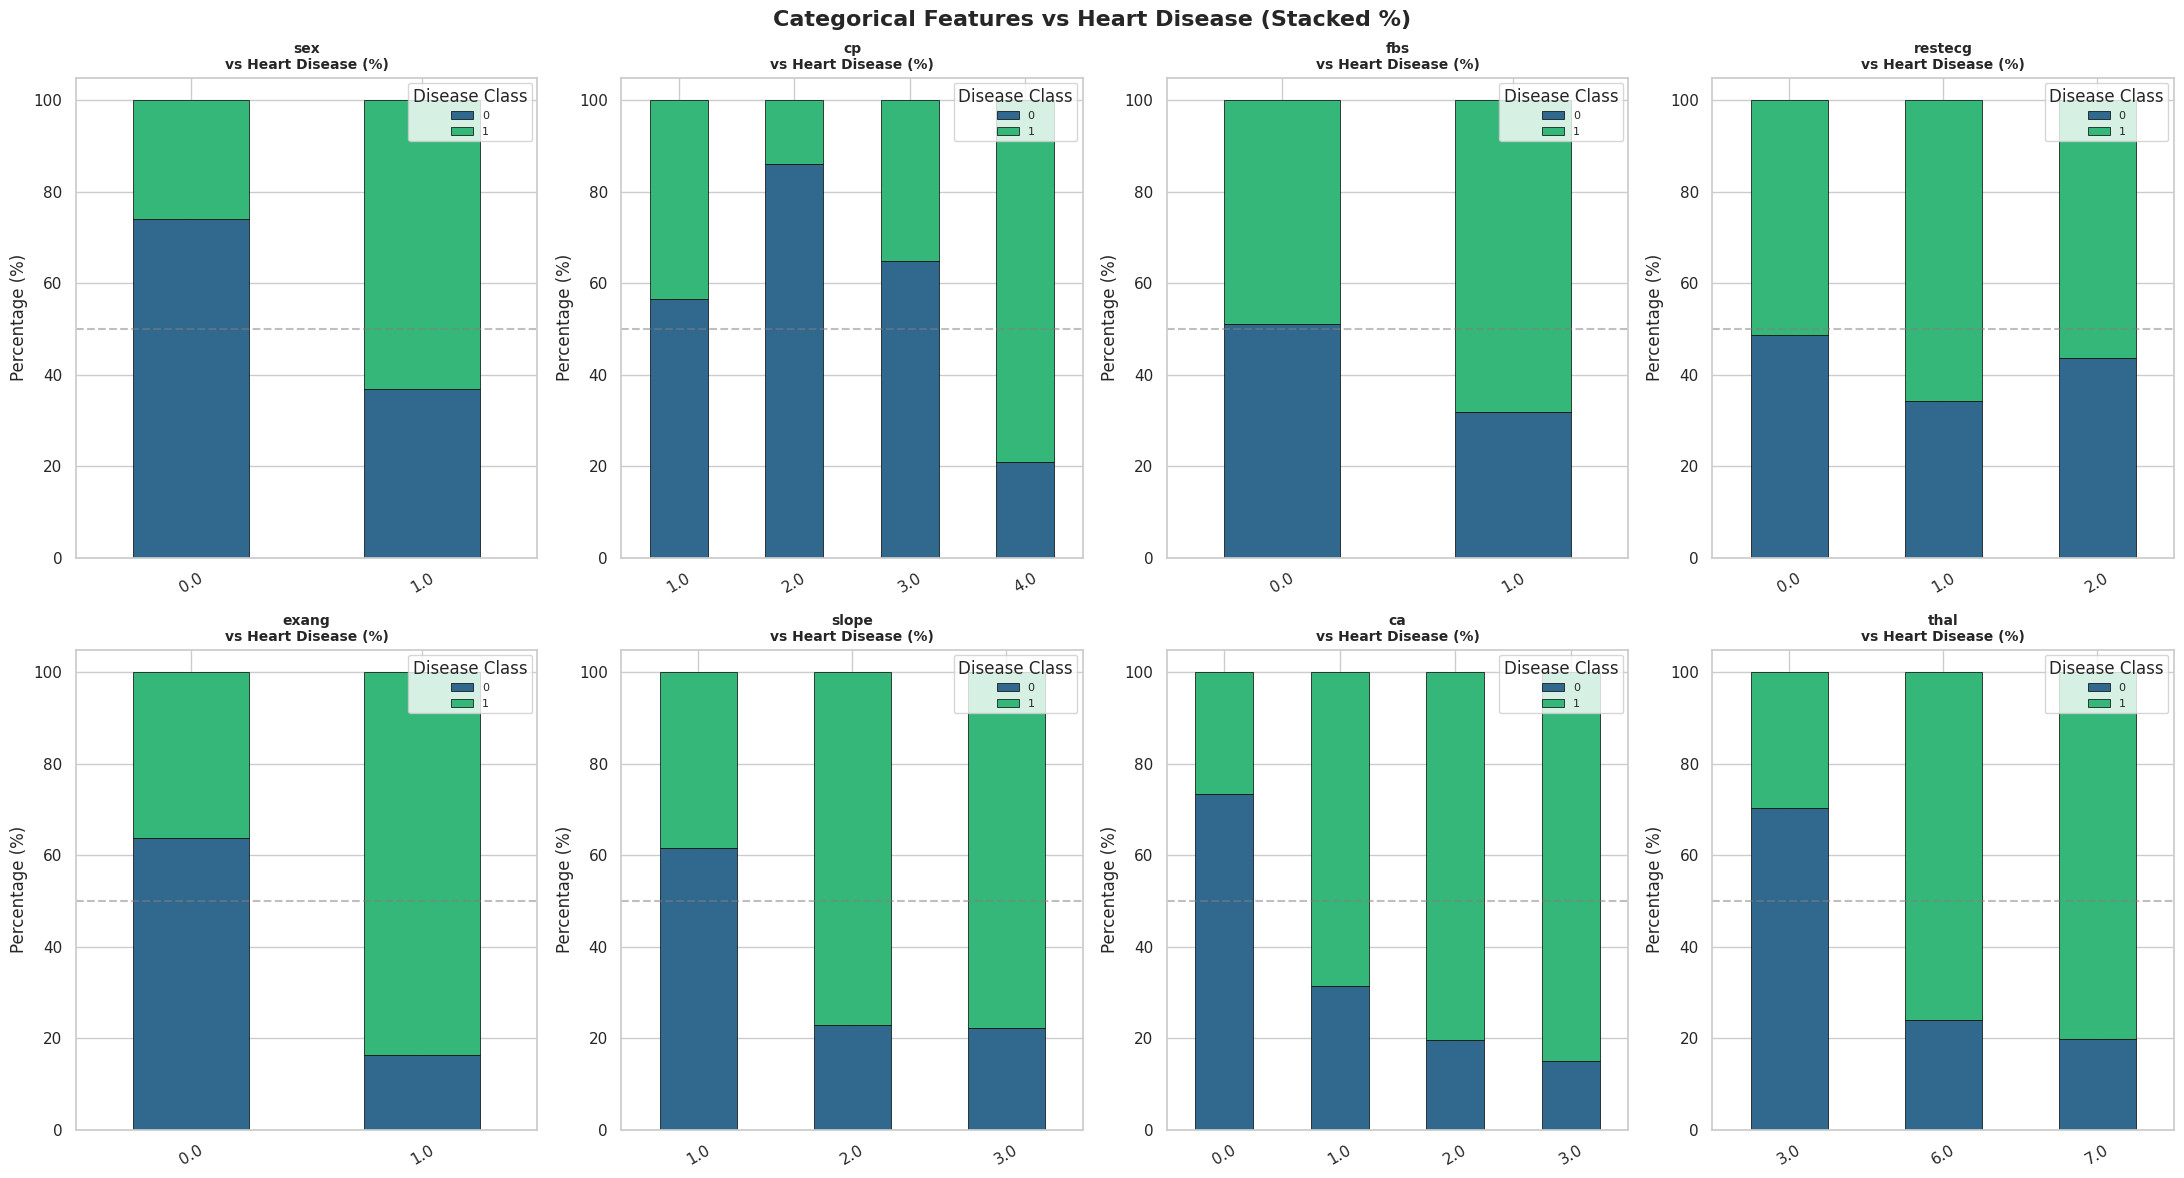

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

num_classes_count = df['num'].nunique()
colors_for_stack = sns.color_palette('viridis', n_colors=num_classes_count)

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['num'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=colors_for_stack, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col}\nvs Heart Disease (%)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Disease Class', fontsize=8)
    axes[i].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Categorical Features vs Heart Disease (Stacked %)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Age Distribution by Heart Disease

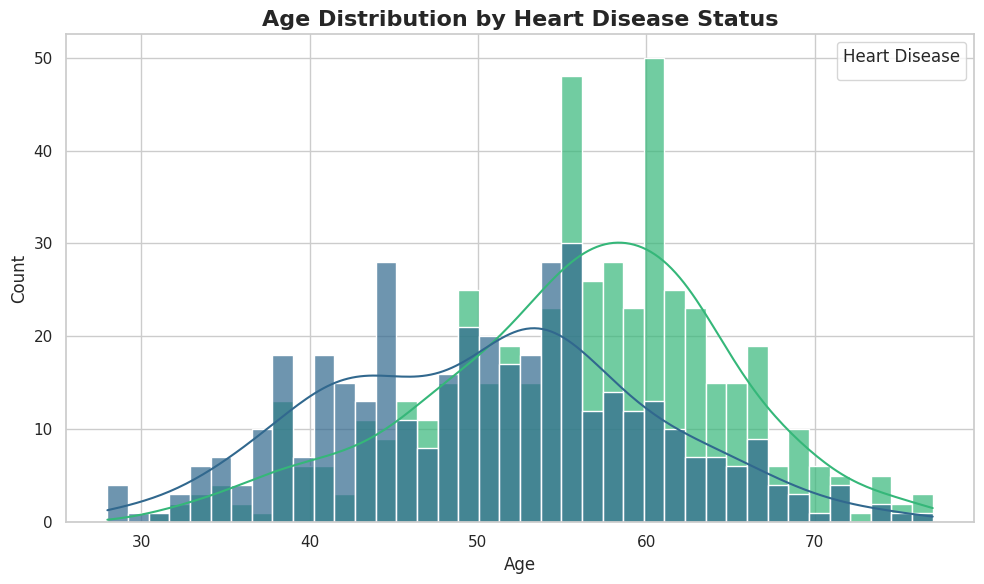

In [22]:
plt.figure(figsize=(10, 6))

unique_num_values = sorted(df['num'].unique())
new_labels = []
for class_val in unique_num_values:
    if class_val == 0:
        new_labels.append('No Disease (0)')
    else:
        new_labels.append(f'Disease ({int(class_val)})')

num_classes_count = df['num'].nunique()
palette_colors = sns.color_palette('viridis', n_colors=num_classes_count)

sns.histplot(data=df, x='age', hue='num', multiple='layer', kde=True,
             palette=palette_colors, ax=plt.gca(), alpha=0.7, bins=40)

plt.title('Age Distribution by Heart Disease Status', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=new_labels, title='Heart Disease')

plt.tight_layout()
plt.show()

We can see that the senior population is more likely to have a heart disease.

### Sex vs Heart Disease

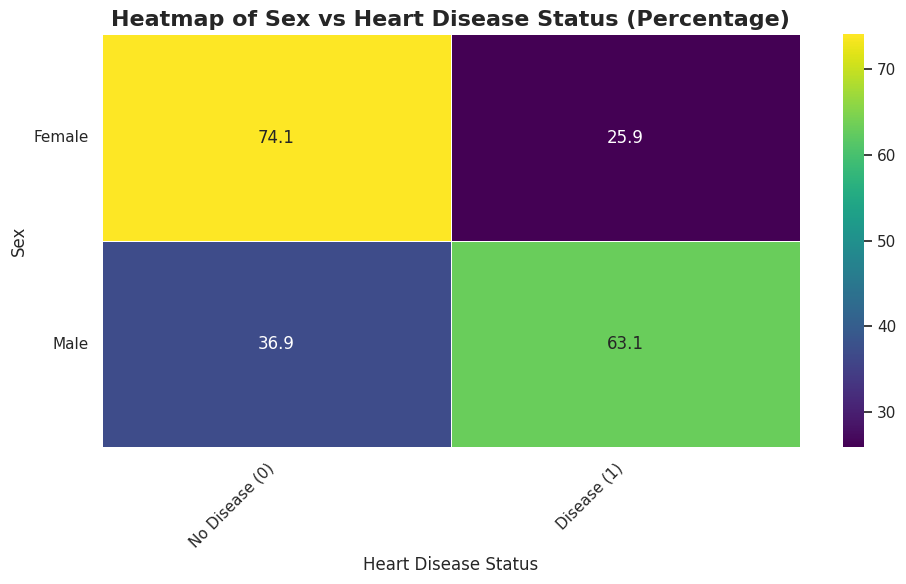

In [23]:
sex_vs_num = pd.crosstab(df['sex'], df['num'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(sex_vs_num, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)

sex_labels = {0: 'Female', 1: 'Male'}
plt.yticks(ticks=np.arange(len(sex_labels)) + 0.5, labels=[sex_labels[i] for i in sorted(sex_labels.keys())], rotation=0)

unique_num_values = sorted(df['num'].unique())
num_labels = []
for class_val in unique_num_values:
    if class_val == 0:
        num_labels.append('No Disease (0)')
    else:
        num_labels.append(f'Disease ({int(class_val)})')
plt.xticks(ticks=np.arange(len(num_labels)) + 0.5, labels=num_labels, rotation=45, ha='right')

plt.title('Heatmap of Sex vs Heart Disease Status (Percentage)', fontsize=16, fontweight='bold')
plt.xlabel('Heart Disease Status', fontsize=12)
plt.ylabel('Sex', fontsize=12)
plt.tight_layout()
plt.show()

The plot shows that heart disease is more common among males for all classes.

### Chest pain vs Heart Disease

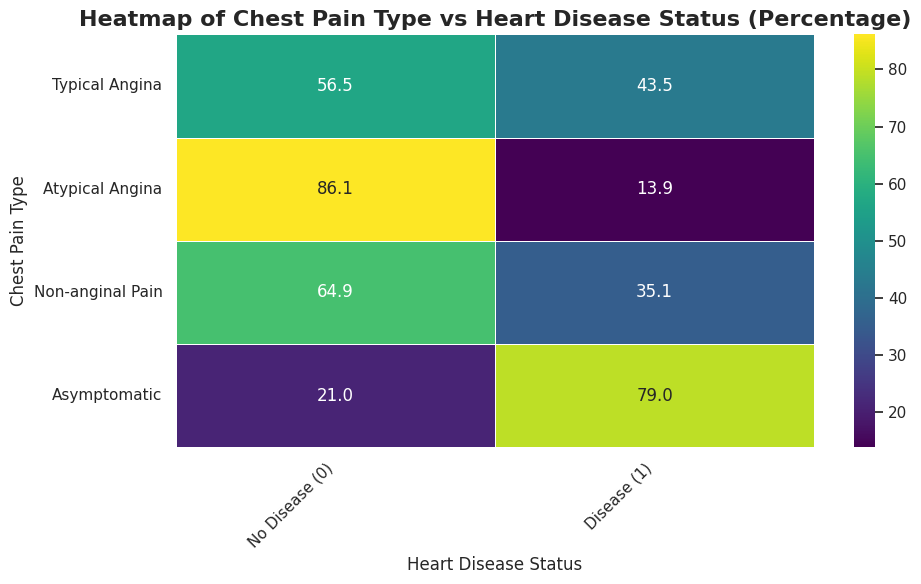

In [24]:
cp_vs_num = pd.crosstab(df['cp'], df['num'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cp_vs_num, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)

cp_labels = {1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-anginal Pain', 4: 'Asymptomatic'}
plt.yticks(ticks=np.arange(len(cp_labels)) + 0.5, labels=[cp_labels[i] for i in sorted(cp_labels.keys())], rotation=0)

unique_num_values = sorted(df['num'].unique())
num_labels = []
for class_val in unique_num_values:
    if class_val == 0:
        num_labels.append('No Disease (0)')
    else:
        num_labels.append(f'Disease ({int(class_val)})')
plt.xticks(ticks=np.arange(len(num_labels)) + 0.5, labels=num_labels, rotation=45, ha='right')

plt.title('Heatmap of Chest Pain Type vs Heart Disease Status (Percentage)', fontsize=16, fontweight='bold')
plt.xlabel('Heart Disease Status', fontsize=12)
plt.ylabel('Chest Pain Type', fontsize=12)
plt.tight_layout()
plt.show()

Interestingly most of the chest pain reported belongs to control group, and asymptomatic chest pain (no symptoms) is more common for patients with heart disease, which leads us to the hypothesis that most heart diseases are "silent killers".

## Correlation Analysis

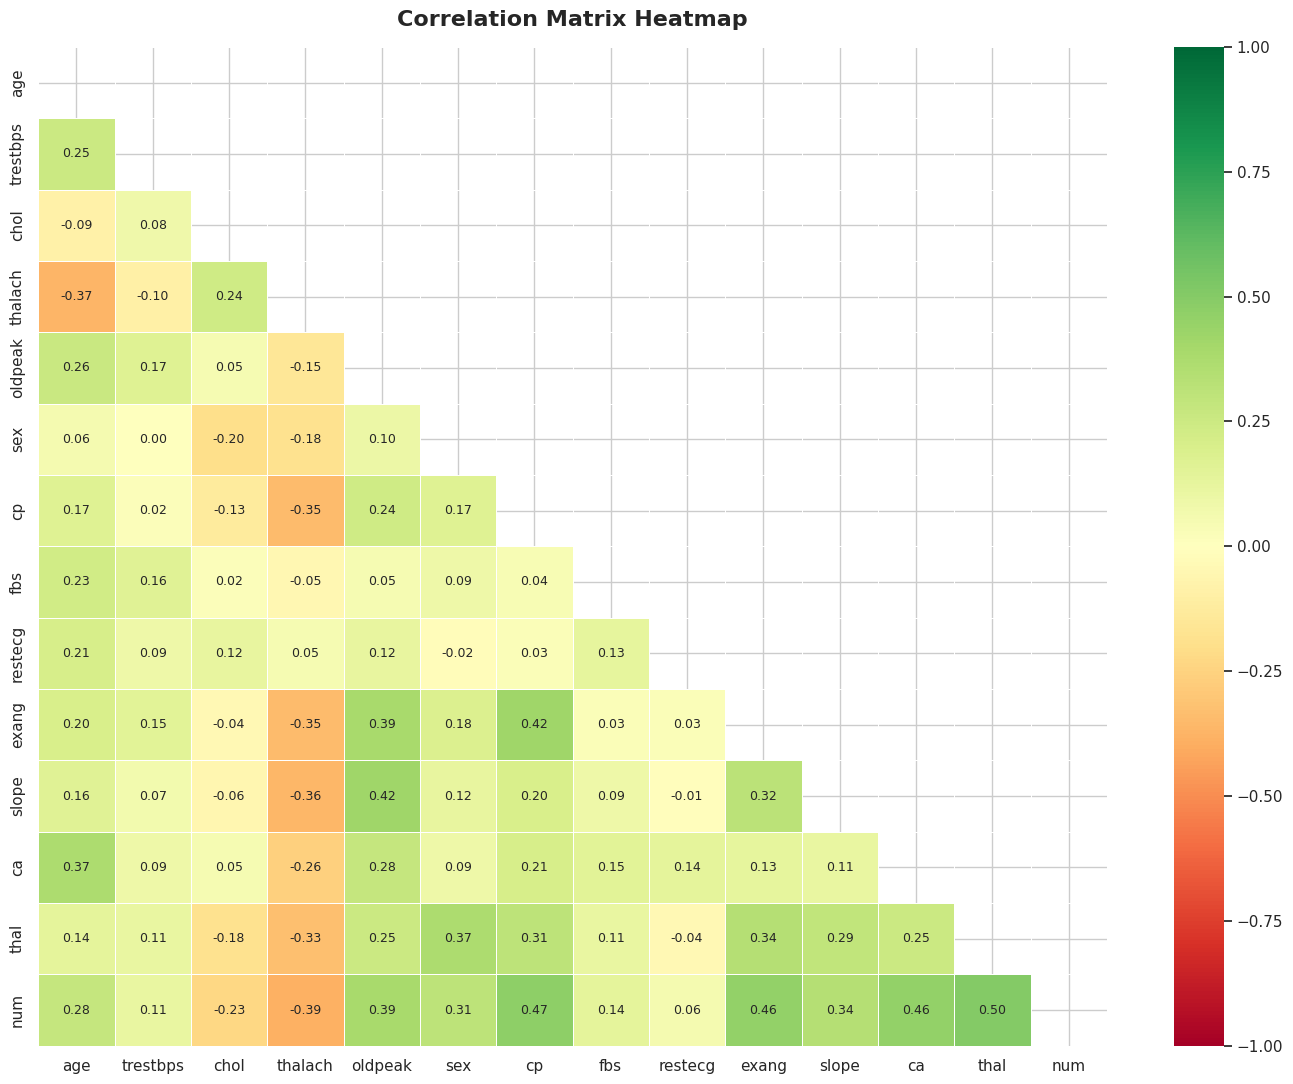

In [25]:
corr_cols = numeric_cols + categorical_cols + ['num']
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

- Resting blood pressure (trestbps) is the weakest predictor of heart disease.
-Resting ecg and fasting blood pressure are also other weak predictors.
- We should focus in the strongly correlated variables such as thalach, thal, ca and oldpeak when doing feature engineering.


## Synthetic Data EDA

In [14]:
#load the csvs from ../data/synthetic
synthetic_dfs = []
for file in os.listdir('../data/synthetic'):
    if file.endswith('.csv'):
        synthetic_dfs.append(pd.read_csv(os.path.join('../data/synthetic', file)))
synthetic_df = pd.concat(synthetic_dfs, ignore_index=True)
synthetic_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,42,1,0,125,210,0,1,140,1,2.5,1,2,1,1
1,53,1,0,140,245,1,1,130,1,2.5,2,1,2,1
2,59,0,0,150,280,1,2,140,1,2.5,2,2,1,1
3,40,0,3,110,190,0,0,160,0,1.5,0,1,1,0
4,71,1,0,160,320,1,1,130,1,3.5,2,2,1,1


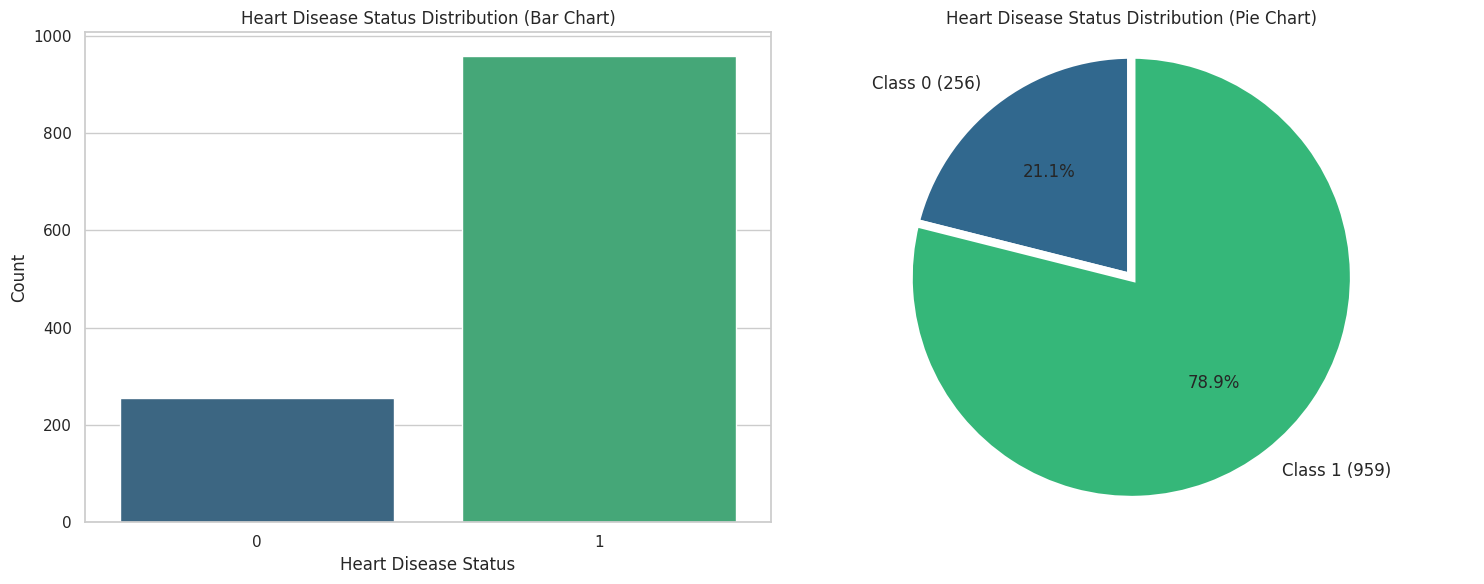

In [27]:
num_classes = synthetic_df['num'].nunique()
colors = sns.color_palette('viridis', n_colors=num_classes)

disease_counts = synthetic_df['num'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar Chart
sns.barplot(x=disease_counts.index, y=disease_counts.values, ax=axes[0], palette=colors)
axes[0].set_title('Heart Disease Status Distribution (Bar Chart)')
axes[0].set_xlabel('Heart Disease Status')
axes[0].set_ylabel('Count')
axes[0].set_xticks(disease_counts.index)

# Pie Chart
wedgeprops = {'edgecolor': 'white', 'linewidth': 6}

pie_labels = [f'Class {i} ({count})' for i, count in disease_counts.items()]
axes[1].pie(disease_counts.values, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops=wedgeprops, textprops={'fontsize': 12})
axes[1].set_title('Heart Disease Status Distribution (Pie Chart)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

In [28]:
#count of classes in the synthetic data
synthetic_target_counts = synthetic_df['num'].value_counts()
print(synthetic_target_counts)

num
1    959
0    256
Name: count, dtype: int64


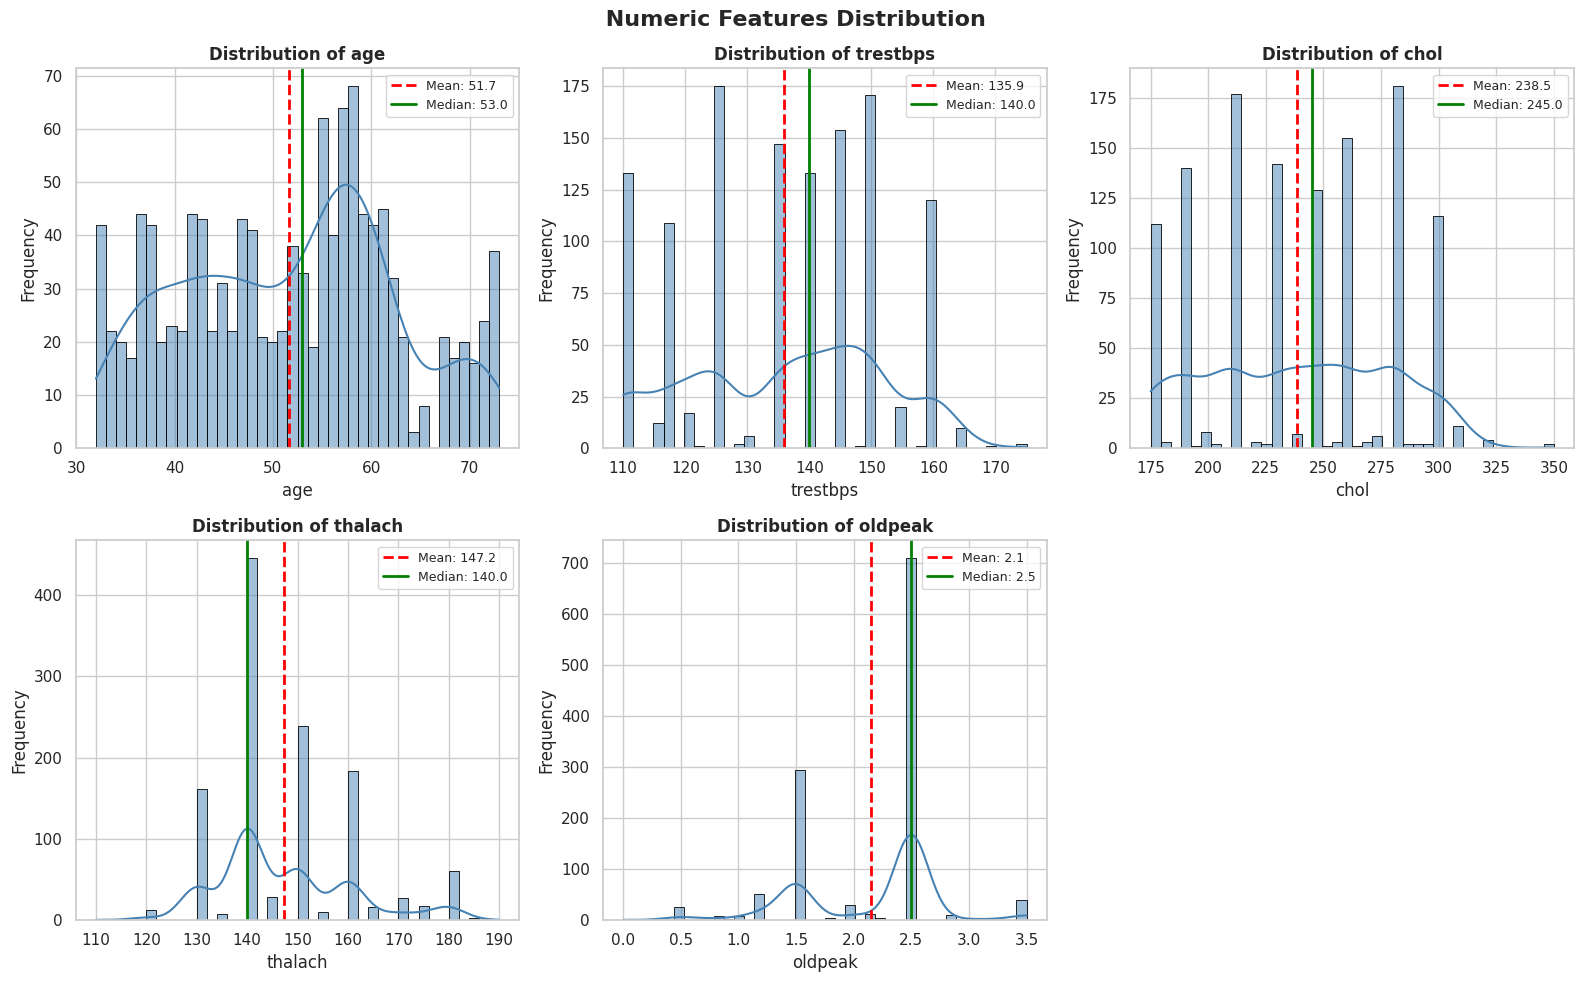

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(synthetic_df[col], bins=40, kde=True, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].axvline(synthetic_df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {synthetic_df[col].mean():.1f}')
    axes[i].axvline(synthetic_df[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {synthetic_df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

axes[5].axis('off')  # Hide last empty subplot
plt.suptitle(' Numeric Features Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

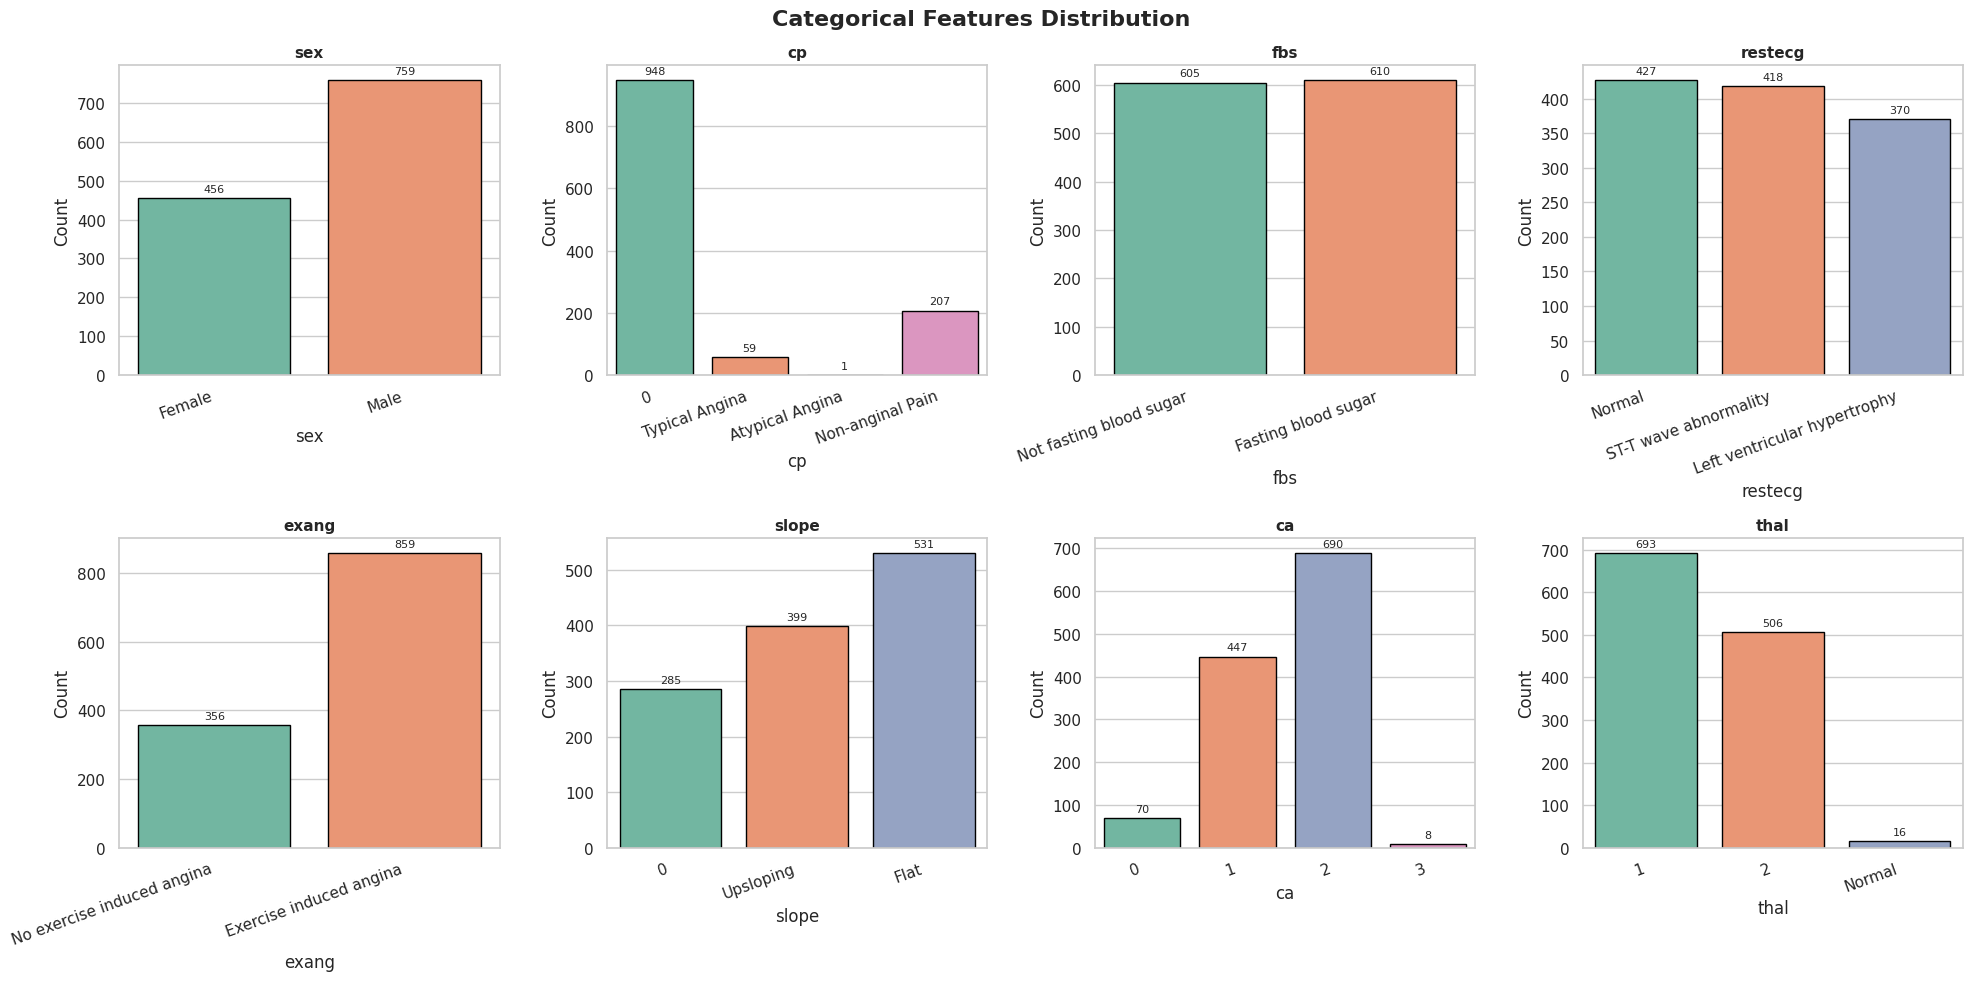

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=synthetic_df, x=col, ax=axes[i], palette='Set2', edgecolor='black')
    val_counts = synthetic_df[col].value_counts().sort_index()
    labels = [cat_labels[col].get(k, str(k)) for k in val_counts.index]


    axes[i].set_xticks(range(len(labels)))
    axes[i].set_xticklabels(labels, rotation=20, ha='right') # Using ha='right' to ensure labels are aligned well

    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=8, padding=3)

plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
#randomly samlple 250 of each class from the synthetic data
sampled_synthetic_df = synthetic_df.groupby('num').apply(lambda x: x.sample(250, random_state=RANDOM_STATE)).reset_index(drop=True)
print(sampled_synthetic_df['num'].value_counts())

num
0    250
1    250
Name: count, dtype: int64


# Data mining

## Train test split


In [16]:
X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (642, 13)
Shape of X_test: (276, 13)
Shape of y_train: (642,)
Shape of y_test: (276,)


#### Missing Value Imputation Strategy

##### 1. Imputation for Categorical Columns

This function imputes missing values in **categorical features** using a machine learning–based approach.

**Steps:**
1. Separate rows with **missing** and **non-missing** values for the target column.
2. Extract input features (**X**) and target variable (**y**) from non-missing rows.
3. Identify other columns containing missing values for later imputation.
4. Encode categorical features using **LabelEncoder**.
5. Encode the target column if it is of **boolean** type.
6. Initialize **IterativeImputer** with **RandomForestRegressor** as the estimator.
7. Impute missing values in other columns of the dataset.
8. Split the data into **training and testing** sets.
9. Train a **RandomForestClassifier** to predict missing values in the target column.
10. Predict missing values and evaluate model **accuracy**.
11. Prepare the dataset containing missing values for final imputation.
12. Impute missing values in the target column for the original missing rows.
13. Predict missing values in the target column.
14. Merge the imputed data back into the **original dataset**.

---

### 2. Imputation for Continuous Columns

This function imputes missing values in **continuous (numerical) features** using regression-based modeling.

**Steps:**
1. Separate rows with **missing** and **non-missing** values for the target column.
2. Extract input features (**X**) and target variable (**y**) from non-missing rows.
3. Identify other columns containing missing values for later imputation.
4. Encode categorical features using **LabelEncoder**.
5. Initialize **IterativeImputer** with **RandomForestRegressor** as the estimator.
6. Impute missing values in other columns of the dataset.
7. Split the data into **training and testing** sets.
8. Train a **RandomForestRegressor** to predict missing values in the target column.
9. Predict missing values and evaluate **performance metrics**.


In [17]:
# Features with multiple categories (Nominal)
categorical_cols = [ 'cp', 'restecg', 'slope', 'thal', 'num']

# Features with only two possible values (Binary/Boolean)
bool_cols = ['sex', 'fbs', 'exang']

# Features with continuous or discrete numerical values
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

In [18]:
missing_data_cols = X_train.isnull().sum()[X_train.isnull().sum() > 0].index.tolist()

In [19]:
def impute_categorical_missing_data(passed_col, X_train, X_test):

    train_null = X_train[X_train[passed_col].isnull()]
    train_not_null = X_train[X_train[passed_col].notnull()]

    X_tr = train_not_null.drop(passed_col, axis=1)
    y_tr = train_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X_tr.columns:
        if X_tr[col].dtype == 'object' or X_tr[col].dtype == 'category':
            X_tr[col] = label_encoder.fit_transform(X_tr[col])

    if passed_col in bool_cols:
        y_tr = label_encoder.fit_transform(y_tr)

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X_tr[col].isnull().sum() > 0:
            col_with_missing_values = X_tr[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X_tr[col] = imputed_values[:, 0]

    # Fit/eval RF on train split only (internal validation)
    X_tr_split, X_val_split, y_tr_split, y_val_split = train_test_split(X_tr, y_tr, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()
    rf_classifier.fit(X_tr_split, y_tr_split)
    y_pred = rf_classifier.predict(X_val_split)

    acc_score = accuracy_score(y_val_split, y_pred)
    print("The feature '" + passed_col + "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    # --- Fill nulls in X_train ---
    if len(train_null) > 0:
        X_null_tr = train_null.drop(passed_col, axis=1)
        for col in X_null_tr.columns:
            if X_null_tr[col].dtype == 'object' or X_null_tr[col].dtype == 'category':
                X_null_tr[col] = label_encoder.fit_transform(X_null_tr[col])
        for col in other_missing_cols:
            if X_null_tr[col].isnull().sum() > 0:
                imputed_values = iterative_imputer.fit_transform(X_null_tr[col].values.reshape(-1, 1))
                X_null_tr[col] = imputed_values[:, 0]

        train_null[passed_col] = rf_classifier.predict(X_null_tr)
        if passed_col in bool_cols:
            train_null[passed_col] = train_null[passed_col].map({0: False, 1: True})

    X_train_imputed = pd.concat([train_not_null, train_null])

    # --- Apply to X_test using the same fitted RF (no refit) ---
    test_null = X_test[X_test[passed_col].isnull()]
    test_not_null = X_test[X_test[passed_col].notnull()]

    if len(test_null) > 0:
        X_null_te = test_null.drop(passed_col, axis=1)
        for col in X_null_te.columns:
            if X_null_te[col].dtype == 'object' or X_null_te[col].dtype == 'category':
                X_null_te[col] = label_encoder.fit_transform(X_null_te[col])
        for col in other_missing_cols:
            if X_null_te[col].isnull().sum() > 0:
                imputed_values = iterative_imputer.fit_transform(X_null_te[col].values.reshape(-1, 1))
                X_null_te[col] = imputed_values[:, 0]

        test_null[passed_col] = rf_classifier.predict(X_null_te)
        if passed_col in bool_cols:
            test_null[passed_col] = test_null[passed_col].map({0: False, 1: True})

    X_test_imputed = pd.concat([test_not_null, test_null])

    return X_train_imputed[passed_col], X_test_imputed[passed_col]


def impute_continuous_missing_data(passed_col, X_train, X_test):

    train_null = X_train[X_train[passed_col].isnull()]
    train_not_null = X_train[X_train[passed_col].notnull()]

    X_tr = train_not_null.drop(passed_col, axis=1)
    y_tr = train_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X_tr.columns:
        if X_tr[col].dtype == 'object' or X_tr[col].dtype == 'category':
            X_tr[col] = label_encoder.fit_transform(X_tr[col])

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X_tr[col].isnull().sum() > 0:
            imputed_values = iterative_imputer.fit_transform(X_tr[col].values.reshape(-1, 1))
            X_tr[col] = imputed_values[:, 0]

    X_tr_split, X_val_split, y_tr_split, y_val_split = train_test_split(X_tr, y_tr, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()
    rf_regressor.fit(X_tr_split, y_tr_split)
    y_pred = rf_regressor.predict(X_val_split)

    print("MAE =", mean_absolute_error(y_val_split, y_pred), "\n")
    print("RMSE =", root_mean_squared_error(y_val_split, y_pred), "\n")
    print("R2 =", r2_score(y_val_split, y_pred), "\n")

    # --- Fill nulls in X_train ---
    if len(train_null) > 0:
        X_null_tr = train_null.drop(passed_col, axis=1)
        for col in X_null_tr.columns:
            if X_null_tr[col].dtype == 'object' or X_null_tr[col].dtype == 'category':
                X_null_tr[col] = label_encoder.fit_transform(X_null_tr[col])
        for col in other_missing_cols:
            if X_null_tr[col].isnull().sum() > 0:
                imputed_values = iterative_imputer.fit_transform(X_null_tr[col].values.reshape(-1, 1))
                X_null_tr[col] = imputed_values[:, 0]
        train_null[passed_col] = rf_regressor.predict(X_null_tr)

    X_train_imputed = pd.concat([train_not_null, train_null])

    test_null = X_test[X_test[passed_col].isnull()]
    test_not_null = X_test[X_test[passed_col].notnull()]

    if len(test_null) > 0:
        X_null_te = test_null.drop(passed_col, axis=1)
        for col in X_null_te.columns:
            if X_null_te[col].dtype == 'object' or X_null_te[col].dtype == 'category':
                X_null_te[col] = label_encoder.fit_transform(X_null_te[col])
        for col in other_missing_cols:
            if X_null_te[col].isnull().sum() > 0:
                imputed_values = iterative_imputer.fit_transform(X_null_te[col].values.reshape(-1, 1))
                X_null_te[col] = imputed_values[:, 0]
        test_null[passed_col] = rf_regressor.predict(X_null_te)

    X_test_imputed = pd.concat([test_not_null, test_null])

    return X_train_imputed[passed_col], X_test_imputed[passed_col]

In [20]:
for col in missing_data_cols:
    if col in categorical_cols or col in bool_cols:
        X_train[col], X_test[col] = impute_categorical_missing_data(col, X_train, X_test)
    elif col in numeric_cols:
        X_train[col], X_test[col] = impute_continuous_missing_data(col, X_train, X_test)

MAE = 13.728760330578512 

RMSE = 17.46428123365701 

R2 = -0.04605412689860677 

MAE = 75.56703999999999 

RMSE = 102.91493574015388 

R2 = 0.11194189147347555 

The feature 'fbs' has been imputed with 76.72 accuracy

The feature 'restecg' has been imputed with 61.72 accuracy

MAE = 15.364132231404959 

RMSE = 19.3205461654745 

R2 = 0.34387869320391895 

The feature 'exang' has been imputed with 83.47 accuracy

MAE = 0.6287166666666667 

RMSE = 1.0022901941719942 

R2 = 0.28271066322088245 

The feature 'slope' has been imputed with 69.05 accuracy

MAE = 0.6267441860465117 

RMSE = 0.8547935967373971 

R2 = -0.18095515734265755 

The feature 'thal' has been imputed with 80.33 accuracy



### Adding synthetic data

In [21]:
#add the synthetic data to the training data
X_train = pd.concat([X_train, sampled_synthetic_df.drop('num', axis=1)], ignore_index=True)
y_train = pd.concat([y_train, sampled_synthetic_df['num']], ignore_index=True)
#priint the shapes after adding synthetic data
print(f"Shape of X_train after adding synthetic data: {X_train.shape}")
print(f"Shape of y_train after adding synthetic data: {y_train.shape}")

Shape of X_train after adding synthetic data: (1142, 13)
Shape of y_train after adding synthetic data: (1142,)


### Scaling

In [22]:
scalers = {}
scaler_key = 'StandardScaler_for_numeric_cols'
# Initialize and store the StandardScaler
scaler_instance = StandardScaler()
scalers[scaler_key] = scaler_instance

# Apply scaling using the stored scaler
X_train[numeric_cols] = scalers[scaler_key].fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scalers[scaler_key].transform(X_test[numeric_cols])

### Encoding

In [23]:
def encode_features(X_train, X_test, bool_cols, categorical_cols):

    X_train = X_train.copy()
    X_test = X_test.copy()

    label_encoder = LabelEncoder()

    for col in bool_cols:
        if col in X_train.columns:
            X_train[col] = label_encoder.fit_transform(X_train[col])
            X_test[col] = label_encoder.transform(X_test[col])

    cat_cols_in_data = [col for col in categorical_cols if col in X_train.columns]

    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    train_encoded = ohe.fit_transform(X_train[cat_cols_in_data])
    test_encoded = ohe.transform(X_test[cat_cols_in_data])

    ohe_feature_names = ohe.get_feature_names_out(cat_cols_in_data)

    train_encoded_df = pd.DataFrame(train_encoded, columns=ohe_feature_names, index=X_train.index)
    test_encoded_df = pd.DataFrame(test_encoded, columns=ohe_feature_names, index=X_test.index)

    X_train = X_train.drop(columns=cat_cols_in_data)
    X_test = X_test.drop(columns=cat_cols_in_data)

    X_train = pd.concat([X_train, train_encoded_df], axis=1)
    X_test = pd.concat([X_test, test_encoded_df], axis=1)

    return X_train, X_test


X_train, X_test = encode_features(X_train, X_test, bool_cols, categorical_cols)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nEncoded columns:\n{X_train.columns.tolist()}")

X_train shape: (1142, 26)
X_test shape: (276, 26)

Encoded columns:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_0.0', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_0.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_1.0', 'thal_2.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']


### K-Fold Cross Validation

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True)

FOLDS = []

for i, (train_indices, test_indices) in enumerate(skf.split(X_train, y_train)):

    FOLDS.append({
        "X" : (X_train.iloc[train_indices], X_train.iloc[test_indices]),
        "y" : (y_train.iloc[train_indices], y_train.iloc[test_indices])
    })

## Modeling & Training

We decided to test 4 models that are dedicated to simple tabular datasets  : `XGBOOST`, `Logestic Regression`, `Random Forest` and `LightGBM`, we decided to go with the following procedure :

- Use K-FOLD to devide our train set into K (4) sets.
- For each model run optuna (A Random Search hyper-parameter optimization library) for a given N times and save the best configurations for each model.
- Re-train each model using the best configuration and run inference on the test set.
- Compare the models' metrics on training set (K-Validation) and pick the best models.
- Evaluate the best model on training set.

In [25]:
CONFIG = {
       "XGBOOST": {
        "n_estimators": {
            "values": (100, 1000),
            "type": "int"
        },
        "max_depth": {
            "values": (3, 12),
            "type": "int"
        },
        "learning_rate": {
            "values": (1e-3, 0.3),
            "type": "float",
            "log": True
        },
        "subsample": {
            "values": (0.5, 1.0),
            "type": "float"
        },
        "colsample_bytree": {
            "values": (0.5, 1.0),
            "type": "float"
        },
        "gamma": {
            "values": (0, 5),
            "type": "float"
        },
        "min_child_weight": {
            "values": (1, 10),
            "type": "int"
        },
        "reg_lambda": {
            "values": (1e-3, 10),
            "type": "float",
            "log": True
        }
    },
}

In [26]:
def sample_params(trial : int, model_name : str, config : dict):

    params = {}

    for param, meta in config[model_name].items():

        values = meta["values"]
        ptype = meta["type"]

        if ptype == "categorical":
            params[param] = trial.suggest_categorical(param, values)

        elif ptype == "int":
            params[param] = trial.suggest_int(param, values[0], values[1])

        elif ptype == "float":
            params[param] = trial.suggest_float(
                param,
                values[0],
                values[1],
                log=meta.get("log", False)
            )

    return params

In [27]:
def build_model(model_name : str, params : dict):

    if model_name == "XGBOOST":

        return XGBClassifier(
            **params,
            tree_method="hist",
            eval_metric="logloss",
            use_label_encoder=False
        )

    elif model_name == "Logistic-Regression":
        return LogisticRegression(**params)

    elif model_name == "Random-Forest":
        return RandomForestClassifier(**params)

    elif model_name == "LightGBM":

        return lgb.LGBMClassifier(
            **params,
            objective="binary",
            metric="auc",
        )

    else:
        raise ValueError("Unknown model")

In [28]:
def run_random_search(folds : list[dict[str, tuple[np.ndarray,np.ndarray]]], model_name : str, config : dict, n_trials : int = 50):

    def objective(trial):

        params = sample_params(trial, model_name, config)
        model = build_model(model_name, params)

        metrics = []

        for fold in folds:
            model = model.fit(fold["X"][0], fold["y"][0])
            y_test_hat = model.predict(fold["X"][1])
            metrics.append(f1_score(fold["y"][1], y_test_hat))

        score = sum(metrics) / len(metrics)

        return score

    study = optuna.create_study(
        direction="maximize",
        sampler=RandomSampler(seed=RANDOM_STATE)
    )

    study.optimize(objective, n_trials=n_trials)

    return study

In [29]:
studies = {}

for model_name in CONFIG:
    print(f"Running random seach on model : {model_name}")
    studies[model_name] = run_random_search(FOLDS, model_name, CONFIG)

Running random seach on model : XGBOOST


In [30]:
best_params = {
    key : study.best_params
    for key, study in studies.items()
}

## Evaluation & Comparison

We re-train each model using the best configuration and compute KFold cross validation metrics the we display comparative plots to highlight the differences in performance between the various models.

In [31]:
def evaluate_models_kfold(models_params : dict[str, dict], folds : list[dict[str, tuple[np.ndarray,np.ndarray]]]):

    results = {}

    for model_name, params in models_params.items():

        fold_metrics = {
            "accuracy": [],
            "f1": [],
            "precision": [],
            "recall": [],
            "auc": [],
            "confusion_matrices": []
        }

        for fold in folds:

            X_train, X_valid = fold["X"]
            y_train, y_valid = fold["y"]

            model = build_model(model_name, params)

            model.fit(X_train, y_train)

            preds = model.predict(X_valid)

            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(X_valid)[:, 1]
            else:
                probs = preds

            fold_metrics["accuracy"].append(
                accuracy_score(y_valid, preds)
            )

            fold_metrics["f1"].append(
                f1_score(y_valid, preds)
            )

            fold_metrics["precision"].append(
                precision_score(y_valid, preds)
            )

            fold_metrics["recall"].append(
                recall_score(y_valid, preds)
            )

            fold_metrics["auc"].append(
                roc_auc_score(y_valid, probs)
            )

            fold_metrics["confusion_matrices"].append(
                confusion_matrix(y_valid, preds)
            )

        summary = {}

        for metric in ["accuracy","f1","precision","recall","auc"]:

            values = np.array(fold_metrics[metric])

            summary[metric] = {
                "values": values,
                "mean": values.mean(),
                "std": values.std()
            }

        summary["confusion_matrices"] = fold_metrics["confusion_matrices"]

        results[model_name] = summary

    return results

In [32]:
results = evaluate_models_kfold(
    best_params,
    FOLDS
)

In [33]:
def plot_metric_comparison(results):

    metrics = ["accuracy","f1","precision","recall","auc"]
    models = list(results.keys())

    fig = make_subplots(
        rows=2,
        cols=3,
        subplot_titles=metrics + [""]
    )

    for idx, metric in enumerate(metrics):

        row = idx // 3 + 1
        col = idx % 3 + 1

        means = [results[m][metric]["mean"] for m in models]
        stds = [results[m][metric]["std"] for m in models]

        labels = [
            f"{mean:.3f} ± {std:.3f}"
            for mean, std in zip(means, stds)
        ]

        fig.add_trace(
            go.Bar(
                x=models,
                y=means,
                error_y=dict(type='data', array=stds),
                text=labels,
                textposition="outside",
                showlegend=False
            ),
            row=row,
            col=col
        )

    fig.update_layout(
        title="Model Comparison Across Metrics",
        height=900,
        width=1000
    )

    fig.show()

In [34]:
def plot_confusion_matrices(results):

    models = list(results.keys())

    fig = make_subplots(
        rows=1,
        cols=len(models),
        subplot_titles=models
    )

    for i, model in enumerate(models):

        cms = np.array(results[model]["confusion_matrices"])

        mean_cm = cms.mean(axis=0)

        fig.add_trace(
            go.Heatmap(
                z=mean_cm,
                text=mean_cm.round(2),
                texttemplate="%{text}",
                showscale=False
            ),
            row=1,
            col=i+1
        )

    fig.update_layout(
        title="Average Confusion Matrix (Across Folds)",
        height=500,
        width=400*len(models)
    )

    fig.show()

In [35]:
plot_metric_comparison(results)

In [70]:
plot_confusion_matrices(results)

- The plots shows that the difference in performance is minimal among models with `XGBOOST`, `Random-Forest` and `LightGBM` have almost the same `F1-Score` and `Accuracy`. `Logestic-Regression` is the worst performing model in terms of all metrics but not by a large margin. We attribute the small differences in to the dataset simplicit.

- From the side-by-side confusion matrix plot it standsout that `Lighgbm` and `XGBOOST` as the model with the least FN (false negatives) i.e it has the lowest number of instances labled as positive but predicated as negative, in medical contexts this is usually desired as we wish to minimize the number of people that carry the disease but mis-predicted as normal.

- From the results of the experiments we pick `XGBOOST` as the chosen model due to the following reasons :

    - Best score across all metrics
    - Lowest FN.
    - Highest inference speed and can also be ran on GPU
    - Scales to datasets with hunderands of thousands of instances which means that as our dataset grows we won't have to change the model.

- However it should be noted that `RandomForest` or `XGBOOST` can be chosen due to the minimal difference in metrics.


- Finally we re-train the best model on the full training set then we evaluate on the test set, this step is important to ensure that our model has the same performance on data that is not available during any phase of the pipeline (hyper-parameter tuning and best model selection).

In [36]:
def final_train_evaluate_log(
    best_model_name,
    best_params,
    X_train,
    y_train,
    X_test,
    y_test
):

    model = build_model(best_model_name, best_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
    }

    print(f"--- {best_model_name} Test Set Metrics ---")
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"F1 Score : {metrics['f1']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"AUC      : {metrics['auc']:.4f}")

    return model

In [37]:
best_model = final_train_evaluate_log(
    'XGBOOST',
    best_params['XGBOOST'],
    X_train,
    y_train,
    X_test,
    y_test
)

--- XGBOOST Test Set Metrics ---
Accuracy : 0.8225
F1 Score : 0.8483
Precision: 0.8059
Recall   : 0.8954
AUC      : 0.9084


In [38]:
#plot metrics in a bar chart
def plot_final_metrics(metrics):

    fig = go.Figure(
        data=[
            go.Bar(
                x=list(metrics.keys()),
                y=list(metrics.values()),
                text=[f"{v:.4f}" for v in metrics.values()],
                textposition="outside"
            )
        ]
    )

    fig.update_layout(
        title="Final Model Performance on Test Set",
        yaxis_title="Score",
        xaxis_title="Metric",
        yaxis=dict(range=[0, 1])
    )

    fig.show()
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else y_pred
final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "auc": roc_auc_score(y_test, y_proba),
}

In [39]:
plot_final_metrics(final_metrics)

In [75]:
### Save the model
path = os.path.join('../data', "synthetic_data_model.pkl")
joblib.dump(best_model, path)

['../data/synthetic_data_model.pkl']